# Function 1 — Bayesian Optimization Campaign

This notebook documents the search for the input `(x1, x2)` that **maximizes** an unknown
("black-box") 2D function. A Gaussian Process (GP) surrogate model is fit to the observed
data, and acquisition functions (Upper Confidence Bound, Expected Improvement) are used to
decide which point to query next. Results were collected over several real query rounds and
appended to the growing dataset as they came in.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C
from sklearn import svm
from sklearn.linear_model import LinearRegression, LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim

## 2. Initial Data

In [2]:
X = np.load("function_1/data/initial_inputs.npy")
y = np.load("function_1/data/initial_outputs.npy")

Additional query rounds, appended as results came in:

In [3]:
new_rows = [np.array(row) for row in [
    [0.959595, 0.858585],  # Week 1 input
    [0.839195, 0.748743],  # Week 2 input
    [0.733668, 0.748743],
    [0.080808, 0.404040],
    [0.727272, 0.737373],
    [0.727272, 0.727272],
    [0.727272, 0.727272],
    [0.727271, 0.727271],
    [0.707070, 0.737373],
    [0.707070, 0.717171],
    [0.686868, 0.727272],
    [0.686868, 0.696969],
    [0.696969, 0.686868],
]]

for row in new_rows:
    X = np.append(X, [row], axis=0)

In [4]:
new_output_rows = [
    [-1.790789192954543e-113],  # Week 1 output
    [-1.3793248852179627e-42],  # Week 2 output
    [-1.7707922454789942e-19],
    [5.34214011784672e-82],
    [4.811276598698796e-16],
    [2.7097266627552453e-14],
    [2.7097266627552453e-14],
    [2.711666244175267e-14],
    [2.14313318892057e-13],
    [3.3176397690319093e-10],
    [6.952409814628062e-10],
    [0.000003061168400631731],
    [0.000003061168400631731],
]

for row in new_output_rows:
    y = np.append(y, row, axis=0)

In [5]:
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Best observed y so far: {max(y)}")

X shape: (23, 2), y shape: (23,)
Best observed y so far: 3.061168400631731e-06


## 3. Exploratory Visualization

The raw outputs span many orders of magnitude (from `1e-113` up to `~1e-3`), so we first
visualize the sampled landscape as-is, then again after a log-transform that makes the
signal usable by the GP.

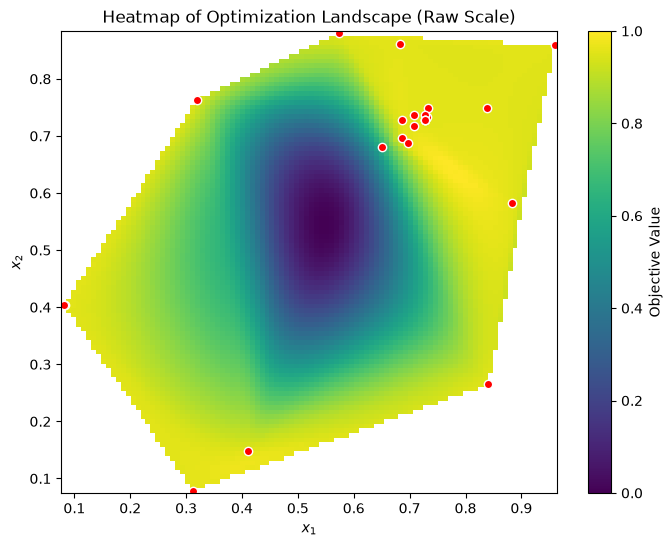

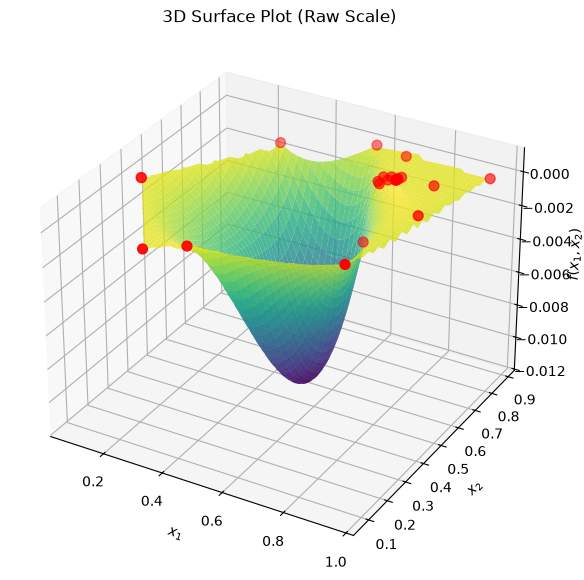

In [6]:
def plot_landscape(X, y, title_suffix=""):
    x_axis, y_axis = X[:, 0], X[:, 1]
    xi = np.linspace(x_axis.min(), x_axis.max(), 100)
    yi = np.linspace(y_axis.min(), y_axis.max(), 100)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x_axis, y_axis), y, (XI, YI), method='cubic')

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(XI, YI, ZI, shading='auto', cmap='viridis')
    plt.scatter(x_axis, y_axis, c='red', edgecolors='white', label='Sample Points')
    plt.colorbar(label='Objective Value')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(f'Heatmap of Optimization Landscape{title_suffix}')
    plt.show()

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XI, YI, ZI, cmap='viridis', alpha=0.8)
    ax.scatter(x_axis, y_axis, y, color='red', s=50)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$f(x_1, x_2)$')
    plt.title(f'3D Surface Plot{title_suffix}')
    plt.show()

plot_landscape(X, y, " (Raw Scale)")

A signed-log transform compresses the huge dynamic range while preserving order and sign,
giving the GP a much more workable target.

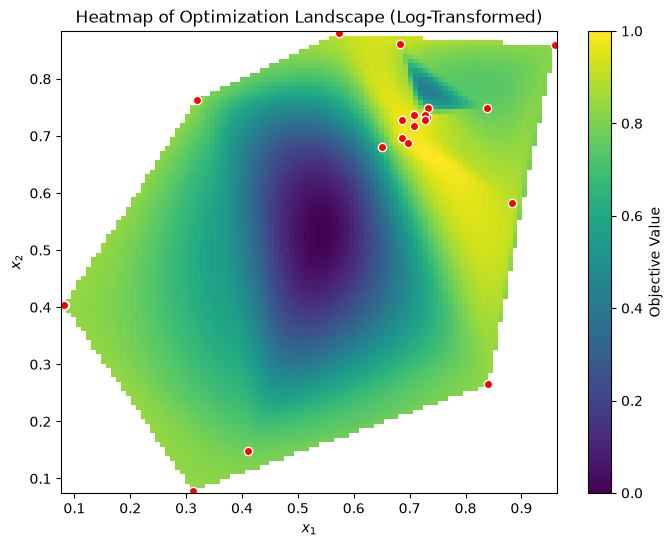

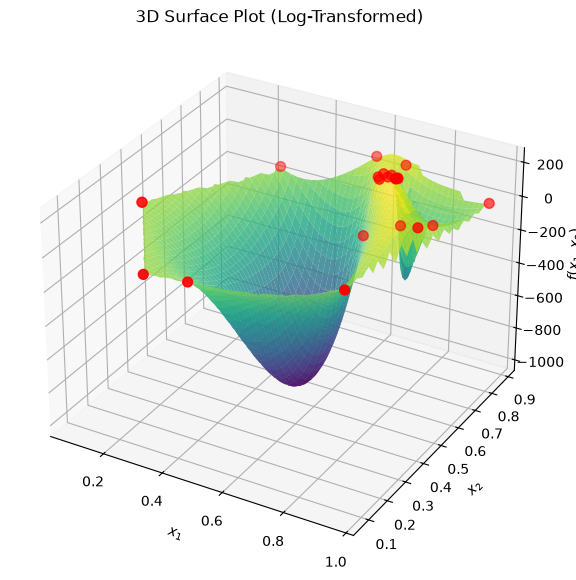

In [7]:
offset = 1e80
y = np.sign(y) * np.log1p(offset * np.abs(y))
plot_landscape(X, y, " (Log-Transformed)")

## 4. Gaussian Process Surrogate Model

In [8]:
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.05, length_scale_bounds=(1e-3, 0.2))

gp_model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-1,              # increased slightly for numerical stability
    n_restarts_optimizer=40  # more restarts help avoid local minima in sharp peaks
)
gp_model.fit(X, y)

x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(0, 1, 100)
x_grid, y_grid = np.meshgrid(x_coords, y_coords)
X_test = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

mean, std = gp_model.predict(X_test, return_std=True)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-emhPt3nG-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 5. Acquisition Functions

### Upper Confidence Bound (UCB)
`kappa` controls the exploration/exploitation trade-off — higher values favor exploring
regions of high uncertainty over exploiting the current best mean prediction.

In [9]:
kappa = 100
ucb = mean + kappa * std
next_idx = np.argmax(ucb)
next_point = X_test[next_idx]

print(f"Suggested Next Iteration Point (UCB): {next_point}")

Suggested Next Iteration Point (UCB): [0.68686869 0.75757576]


### Expected Improvement (EI)
`xi` is the exploration parameter — higher values require a larger expected improvement
over the current best before a point is favored.

In [10]:
def expected_improvement(X, model, current_best, xi=0):
    mu, sigma = model.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    mask = sigma > 0
    ei = np.zeros_like(mu)

    improvement = mu[mask] - current_best - xi
    z = improvement / sigma[mask]

    ei[mask] = (improvement * norm.cdf(z) +
                sigma[mask] * norm.pdf(z))

    return ei

current_best_y = np.max(y)
ei_values = expected_improvement(X_test, gp_model, current_best_y, xi=100)
next_idx = np.argmax(ei_values)
next_point = X_test[next_idx]
print(f"Suggested Next Iteration Point (EI): {next_point}")

Suggested Next Iteration Point (EI): [0.6969697  0.72727273]


Next iteration: continue exploring the space, guided by the heatmap and 3D surface plots above.

## 6. Supplementary Analysis — Alternative Candidate-Screening Methods

The methods below are exploratory side-analyses, not part of the core GP/acquisition-function
decision loop. Existing samples are manually labeled "positive" (high-yield, indices
`[4, 9, 10, 11, 12]`) or "negative", and a few classifiers are trained on that split as a
sanity check on whether the acquisition function's suggested `next_point` also looks
promising from a classification standpoint.

### SVM Classification

In [11]:
kernels = ['linear', 'rbf', 'poly']

y_labels = np.zeros(len(X))
positive_indices = [4, 9, 10, 11, 12]
y_labels[positive_indices] = 1

for k in kernels:
    clf = svm.SVC(kernel=k, C=20.0, gamma='scale', degree=3)
    clf.fit(X, y_labels)

    print(f"Kernel: {k}")
    print(f"Number of Support Vectors: {sum(clf.n_support_)}")

    support_vector_indices = clf.support_
    support_vectors = clf.support_vectors_
    n_per_class = clf.n_support_

    print(f"Indices of support vectors: {support_vector_indices}")
    print(f"Support Vector Coordinates:\n {support_vectors}")
    print(f"Number of support vectors for each class: {n_per_class}")

    predictions = clf.predict([next_point])
    scores = clf.decision_function([next_point])

    for i, (pred, score) in enumerate(zip(predictions, scores)):
        print(f"Sample {i} | Predicted Class: {pred} | Distance from Margin: {score:.4f}")
    print()

Kernel: linear
Number of Support Vectors: 11
Indices of support vectors: [ 2  3 14 15 16 17  4  9 10 11 12]
Support Vector Coordinates:
 [[0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.727272   0.737373  ]
 [0.727272   0.727272  ]
 [0.727272   0.727272  ]
 [0.727271   0.727271  ]
 [0.65011406 0.68152635]
 [0.88388983 0.58225397]
 [0.959595   0.858585  ]
 [0.839195   0.748743  ]
 [0.733668   0.748743  ]]
Number of support vectors for each class: [6 5]
Sample 0 | Predicted Class: 0.0 | Distance from Margin: -1.2287

Kernel: rbf
Number of Support Vectors: 13
Indices of support vectors: [ 0  2  3  5  6  8 13 15 16  4  9 11 12]
Support Vector Coordinates:
 [[0.31940389 0.76295937]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.08250725 0.40348751]
 [0.080808   0.40404   ]
 [0.727272   0.727272  ]
 [0.727272   0.727272  ]
 [0.65011406 0.68152635]
 [0.88388983 0.58225397]
 [0.839195   0.748743  ]
 [0.733668   0.748743  ]]
Number o

### Linear Regression

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

prediction = lin_reg.predict([next_point])
print(f"Linear Regression Prediction: {prediction[0]:.6f}")
print(f"Coefficients: {lin_reg.coef_}, Intercept: {lin_reg.intercept_}")

Linear Regression Prediction: 73.865875
Coefficients: [ 38.80701289 132.58958793], Intercept: -49.61022778283937


### Logistic Regression

In [13]:
log_reg = LogisticRegression()
log_reg.fit(X, y_labels)

prob = log_reg.predict_proba([next_point])
print(f"Probability of Class 0 vs Class 1: {prob}")

label = log_reg.predict([next_point])
print(f"Predicted Class: {label}")

Probability of Class 0 vs Class 1: [[0.7712574 0.2287426]]
Predicted Class: [0.]


### Neural Network Saliency — Shallow (Logistic-Regression-Style)

In [14]:
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)
y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

nn_model_shallow = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

optimizer = optim.SGD(nn_model_shallow.parameters(), lr=0.1)
criterion = nn.BCELoss()

for _ in range(1000):
    optimizer.zero_grad()
    outputs = nn_model_shallow(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

# Gradient of the output w.r.t. each input point ("support vector" style importance)
nn_model_shallow.zero_grad()
output = nn_model_shallow(X_tensor)
output.backward(torch.ones_like(output))

importance_scores = X_tensor.grad.abs().sum(dim=1).detach().numpy()
raw_gradients = X_tensor.grad.detach().numpy()

print("Point Index | Gradient (x1) | Gradient (x2) | Total Importance")
for i, score in enumerate(importance_scores):
    print(f"Index {i:2d}    | {raw_gradients[i][0]:.4f}      | {raw_gradients[i][1]:.4f}      | {score:.4f}")

Point Index | Gradient (x1) | Gradient (x2) | Total Importance
Index  0    | 8.1493      | 1.6052      | 9.7545
Index  1    | 11.0213      | 2.1173      | 13.1386
Index  2    | 12.6424      | 2.4021      | 15.0445
Index  3    | 12.9919      | 2.4570      | 15.4489
Index  4    | -36.2061      | -6.7957      | 43.0018
Index  5    | 7.9803      | 1.5666      | 9.5469
Index  6    | 7.0520      | 1.3998      | 8.4518
Index  7    | 12.3203      | 2.3470      | 14.6672
Index  8    | 5.8123      | 1.1814      | 6.9937
Index  9    | -33.3565      | -6.2935      | 39.6500
Index 10    | -31.5402      | -5.9688      | 37.5090
Index 11    | -33.5716      | -6.3290      | 39.9006
Index 12    | -35.0008      | -6.5815      | 41.5823
Index 13    | 5.8019      | 1.1795      | 6.9814
Index 14    | 12.6037      | 2.3953      | 14.9989
Index 15    | 12.5805      | 2.3910      | 14.9715
Index 16    | 12.5805      | 2.3910      | 14.9715
Index 17    | 12.5804      | 2.3910      | 14.9715
Index 18    | 12.34

In [15]:
nn_model_shallow.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_shallow(sample_input)

print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.2476
Predicted Class: 0


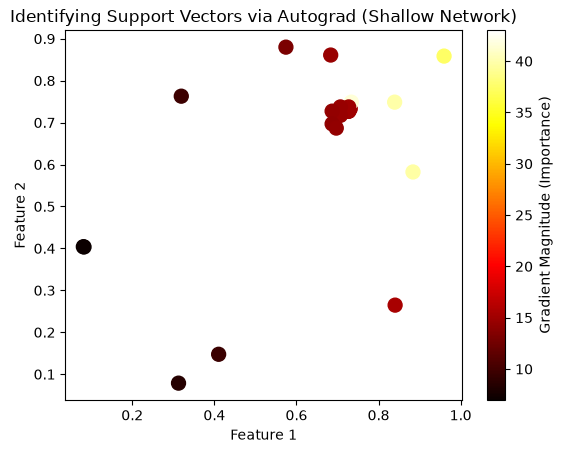

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=importance_scores, cmap='hot', s=100)
plt.colorbar(label='Gradient Magnitude (Importance)')
plt.title('Identifying Support Vectors via Autograd (Shallow Network)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Neural Network Saliency — Deep

In [17]:
nn_model_deep = nn.Sequential(
    nn.Linear(2, 10),
    nn.ReLU(),
    nn.Linear(10, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(nn_model_deep.parameters(), lr=0.01)
criterion = nn.BCELoss()

for _ in range(2000):
    optimizer.zero_grad()
    outputs = nn_model_deep(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

X_tensor.grad.zero_()
output = nn_model_deep(X_tensor)
output.backward(torch.ones_like(output))

deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")

Point | Deep Importance Score
 0    | 0.0005
 1    | 0.6650
 2    | 5.0638
 3    | 3.9832
 4    | 1.0306
 5    | 0.0034
 6    | 0.0019
 7    | 4.3392
 8    | 0.0002
 9    | 4.7149
10    | 0.2816
11    | 4.6651
12    | 5.4525
13    | 0.0002
14    | 4.9175
15    | 4.7581
16    | 4.7581
17    | 4.7580
18    | 3.7624
19    | 3.4625
20    | 2.6057
21    | 2.2535
22    | 2.5632


In [18]:
nn_model_deep.eval()
sample_input = torch.tensor(np.array([next_point]), dtype=torch.float32)

with torch.no_grad():
    prediction_prob = nn_model_deep(sample_input)

print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")

Probability of being Positive (Class 1): 0.1277
Predicted Class: 0


## 7. Results Summary

Observed yield over the most recent iterations:

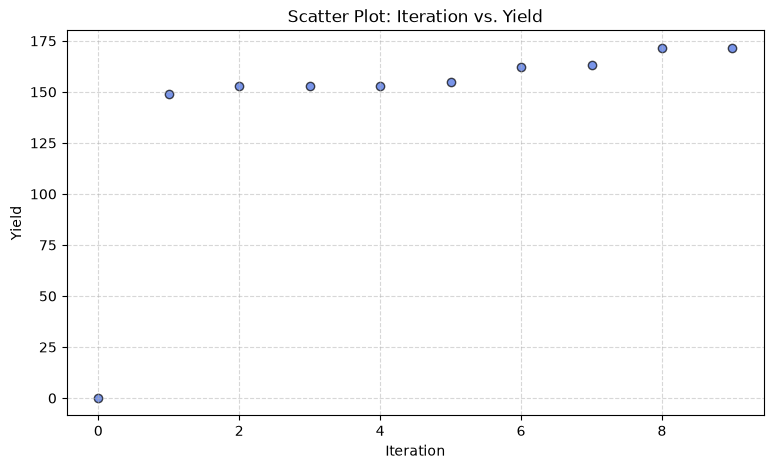

In [19]:
plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0, 10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()